# Sentiment Model — Frustration Classification

**Proposito:** Entrenar un modelo supervisado para predecir `nivel_frustracion` (0/1/2) y compararlo contra el baseline deterministico descubierto en el EDA.

- Target: `nivel_frustracion` (ordinal, 3 clases, desbalanceado)
- Input: `texto_clean` + features contextuales
- Baseline deterministico: reglas basadas en `turn_number` + `resolved` (~100% accuracy)
- Dataset: `data/processed/data_preprocessed.csv`

## 1. IMPORTS Y CONFIGURACION

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
from pathlib import Path
import json

# Scikit-learn
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    ConfusionMatrixDisplay
)

warnings.filterwarnings('ignore')

# Constantes
RANDOM_STATE = 42
DATA_PATH = Path('../data/processed/data_preprocessed.csv')
MODELS_PATH = Path('../models/')
MODELS_PATH.mkdir(exist_ok=True)
FIGURES_PATH = Path('../reports/figures/')
FIGURES_PATH.mkdir(exist_ok=True)

# Plotting
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')
sns.set_palette('Set2')

## 2. CARGA Y PREPARACION

In [2]:
df = pd.read_csv(DATA_PATH)
print(f'Dataset: {df.shape[0]} filas x {df.shape[1]} columnas')

# Target
y = np.asarray(df['nivel_frustracion'], dtype=np.int64)
print(f'Target distribution: {np.bincount(y)}')
print(f'  Clase 0: {np.sum(y == 0):>6} ({np.mean(y == 0)*100:>5.1f}%)')
print(f'  Clase 1: {np.sum(y == 1):>6} ({np.mean(y == 1)*100:>5.1f}%)')
print(f'  Clase 2: {np.sum(y == 2):>6} ({np.mean(y == 2)*100:>5.1f}%)')

Dataset: 20001 filas x 15 columnas
Target distribution: [10970  6667  2364]
  Clase 0:  10970 ( 54.8%)
  Clase 1:   6667 ( 33.3%)
  Clase 2:   2364 ( 11.8%)


---
## 3. BASELINE DETERMINISTICO

Del EDA descubrimos que la frustracion sigue una regla exacta:

```
Turno 1 → frustracion = 0
Turno 2 → frustracion = 1
Turno 3:
  - Si resolved = 1 → frustracion = 0
  - Si resolved = 0 → frustracion = 2
```

Esto deberia dar exactamente 100% de precision porque el dataset es deterministico.

=== BASELINE DETERMINISTICO ===
Accuracy: 100.00%
F1-weighted: 1.0000
F1-macro: 1.0000



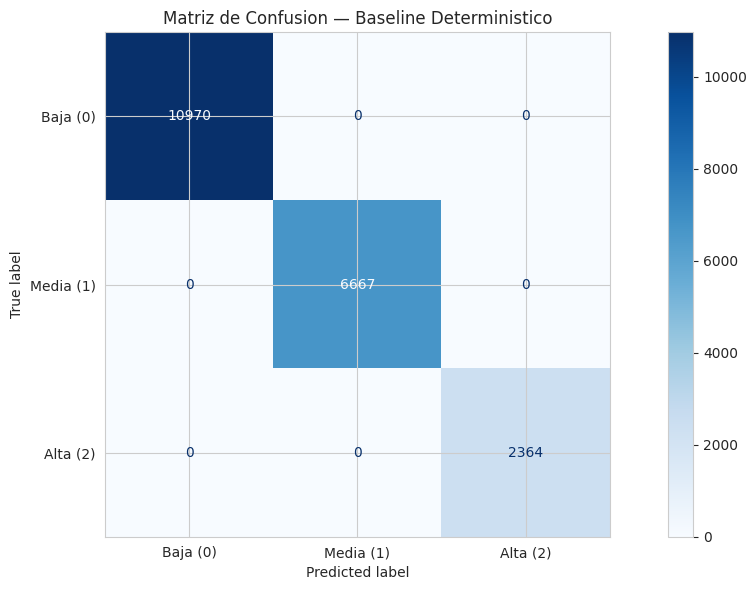


Classification Report:
              precision    recall  f1-score   support

    Baja (0)       1.00      1.00      1.00     10970
   Media (1)       1.00      1.00      1.00      6667
    Alta (2)       1.00      1.00      1.00      2364

    accuracy                           1.00     20001
   macro avg       1.00      1.00      1.00     20001
weighted avg       1.00      1.00      1.00     20001



In [3]:
# Baseline deterministico: reglas del EDA
def deterministic_baseline(df):
    """Predice frustracion usando reglas basadas en turn_number y resolved."""
    pred = np.zeros(len(df), dtype=int)
    
    # Turno 1 = 0
    pred[df['turn_number'] == 1] = 0
    
    # Turno 2 = 1
    pred[df['turn_number'] == 2] = 1
    
    # Turno 3: resolved=1 → 0, resolved=0 → 2
    mask_t3 = df['turn_number'] == 3
    pred[mask_t3 & (df['resolved'] == 1)] = 0
    pred[mask_t3 & (df['resolved'] == 0)] = 2
    
    return pred

y_baseline = deterministic_baseline(df)

# Evaluacion del baseline
print('=== BASELINE DETERMINISTICO ===')
print(f'Accuracy: {(y_baseline == y).mean()*100:.2f}%')
print(f'F1-weighted: {f1_score(y, y_baseline, average="weighted"):.4f}')
print(f'F1-macro: {f1_score(y, y_baseline, average="macro"):.4f}')
print()

# Matriz de confusion
cm = confusion_matrix(y, y_baseline)
disp = ConfusionMatrixDisplay(cm, display_labels=['Baja (0)', 'Media (1)', 'Alta (2)'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Matriz de Confusion — Baseline Deterministico')
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'baseline_deterministico.png', bbox_inches='tight')
plt.show()

print('\nClassification Report:')
print(classification_report(y, y_baseline, target_names=['Baja (0)', 'Media (1)', 'Alta (2)']))

---
## 4. TRAIN / TEST SPLIT

Separamos datos de texto y contextuales. 

**Importante:** El split debe ser estratificado por `nivel_frustracion` para mantener la proporcion de clases.

In [4]:
# Features
X_text = np.asarray(df['texto_clean'])
X_context = df[['turn_number', 'flow_name', 'usuario']].copy()

# Split estratificado 70/15/15 (train/val/test)
# Primero separamos test
X_text_temp, X_text_test, X_ctx_temp, X_ctx_test, y_temp, y_test = train_test_split(
    X_text, X_context, y,
    test_size=0.15, random_state=RANDOM_STATE, stratify=y
)

# Luego separamos train y validation del resto
X_text_train, X_text_val, X_ctx_train, X_ctx_val, y_train, y_val = train_test_split(
    X_text_temp, X_ctx_temp, y_temp,
    test_size=0.15/0.85, random_state=RANDOM_STATE, stratify=y_temp
)

print(f'Train: {len(y_train)} ({np.mean(y_train == 0)*100:.0f}%/{np.mean(y_train == 1)*100:.0f}%/{np.mean(y_train == 2)*100:.0f}%)')
print(f'Val:   {len(y_val)} ({np.mean(y_val == 0)*100:.0f}%/{np.mean(y_val == 1)*100:.0f}%/{np.mean(y_val == 2)*100:.0f}%)')
print(f'Test:  {len(y_test)} ({np.mean(y_test == 0)*100:.0f}%/{np.mean(y_test == 1)*100:.0f}%/{np.mean(y_test == 2)*100:.0f}%)')
print(f'\nEstratificacion correcta: {np.bincount(y)/len(y) * 100}')
print(f'Train: {np.bincount(y_train)/len(y_train) * 100}')
print(f'Val:   {np.bincount(y_val)/len(y_val) * 100}')
print(f'Test:  {np.bincount(y_test)/len(y_test) * 100}')

Train: 14000 (55%/33%/12%)
Val:   3000 (55%/33%/12%)
Test:  3001 (55%/33%/12%)

Estratificacion correcta: [54.84725764 33.33333333 11.81940903]
Train: [54.85       33.33571429 11.81428571]
Val:   [54.83333333 33.33333333 11.83333333]
Test:  [54.84838387 33.32222592 11.8293902 ]


---
## 5. PIPELINE SUPERVISADO

Construimos un pipeline con:
- `TfidfVectorizer` para el texto
- `ColumnTransformer` para combinar features de texto y contextuales
- `RandomForestClassifier` con `class_weight='balanced'` para el desbalanceo

In [5]:
# Pipeline de texto
text_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=5000,
        stop_words=None,  # texto_clean ya esta normalizado
        max_df=0.95,
        min_df=5
    ))
])

In [6]:

# Preprocesamiento de features contextuales
contextual_features = Pipeline([
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

# ColumnTransformer unifica texto y contexto
preprocessor = ColumnTransformer([
    ('text', text_pipeline, 'texto'),
    ('context', contextual_features, ['turn_number', 'flow_name', 'usuario'])
])

In [7]:
# Pipeline completo
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

# Armamos X_train como DataFrame para que ColumnTransformer sepa las columnas
X_train_df = pd.DataFrame({
    'texto': X_text_train,
    'turn_number': X_ctx_train['turn_number'],
    'flow_name': X_ctx_train['flow_name'],
    'usuario': X_ctx_train['usuario']
})

print('Pipeline structure:')
print(pipeline)

Pipeline structure:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('text',
                                                  Pipeline(steps=[('tfidf',
                                                                   TfidfVectorizer(max_df=0.95,
                                                                                   max_features=5000,
                                                                                   min_df=5,
                                                                                   ngram_range=(1,
                                                                                                2)))]),
                                                  'texto'),
                                                 ('context',
                                                  Pipeline(steps=[('encoder',
                                                                   OrdinalEncoder(handle_unknown='use_encoded_value',
  

## 6. ENTRENAMIENTO

In [8]:
print('Entrenando modelo...')
pipeline.fit(X_train_df, y_train)
print('Entrenamiento completado.')

Entrenando modelo...
Entrenamiento completado.


## 7. EVALUACION EN VALIDACION

In [9]:
X_val_df = pd.DataFrame({
    'texto': X_text_val,
    'turn_number': X_ctx_val['turn_number'],
    'flow_name': X_ctx_val['flow_name'],
    'usuario': X_ctx_val['usuario']
})

y_val_pred = pipeline.predict(X_val_df)

print('=== RANDOMFOREST — VALIDATION SET ===')
print(f'Accuracy: {(y_val_pred == y_val).mean()*100:.2f}%')
print(f'F1-weighted: {f1_score(y_val, y_val_pred, average="weighted"):.4f}')
print(f'F1-macro: {f1_score(y_val, y_val_pred, average="macro"):.4f}')
print()
print('Classification Report:')
print(classification_report(y_val, y_val_pred, target_names=['Baja (0)', 'Media (1)', 'Alta (2)']))

=== RANDOMFOREST — VALIDATION SET ===
Accuracy: 100.00%
F1-weighted: 1.0000
F1-macro: 1.0000

Classification Report:
              precision    recall  f1-score   support

    Baja (0)       1.00      1.00      1.00      1645
   Media (1)       1.00      1.00      1.00      1000
    Alta (2)       1.00      1.00      1.00       355

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted avg       1.00      1.00      1.00      3000



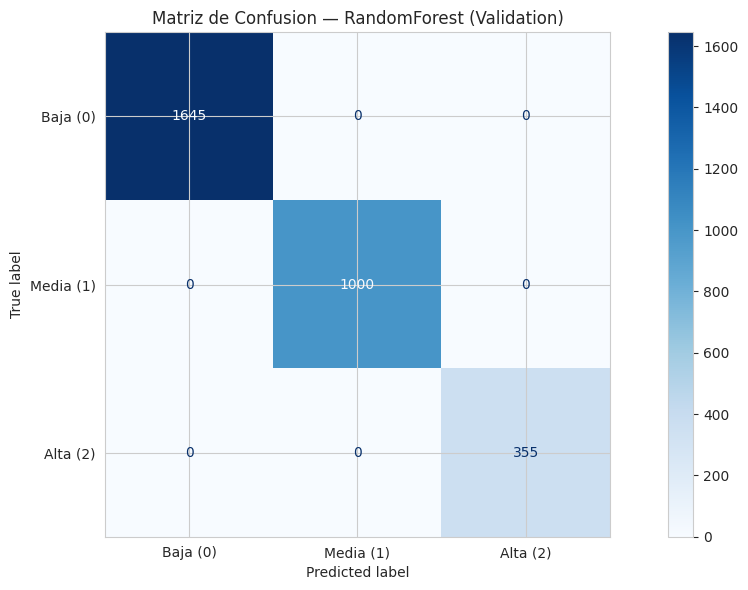

In [10]:
# Matriz de confusion — validation
cm_val = confusion_matrix(y_val, y_val_pred)
disp = ConfusionMatrixDisplay(cm_val, display_labels=['Baja (0)', 'Media (1)', 'Alta (2)'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Matriz de Confusion — RandomForest (Validation)')
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'rf_validation_confusion.png', bbox_inches='tight')
plt.show()

---
## 8. COMPARACION: BASELINE vs RANDOMFOREST

In [11]:
# Baseline en validation set
val_df = pd.DataFrame({
    'turn_number': np.asarray(X_ctx_val['turn_number']),
    'resolved': np.asarray(df.loc[X_ctx_val.index, 'resolved'])
})
y_val_baseline = deterministic_baseline(val_df)

print('=== COMPARACION EN VALIDATION SET ===')
print(f'{"Metrica":<20} {"Baseline":<12} {"RandomForest":<12}')
print('-' * 44)

baseline_acc = (y_val_baseline == y_val).mean()
rf_acc = (y_val_pred == y_val).mean()
print(f'{"Accuracy":<20} {baseline_acc*100:<10.2f}% {rf_acc*100:<10.2f}%')

baseline_f1w = f1_score(y_val, y_val_baseline, average='weighted')
rf_f1w = f1_score(y_val, y_val_pred, average='weighted')
print(f'{"F1-weighted":<20} {baseline_f1w:<12.4f} {rf_f1w:<12.4f}')

baseline_f1m = f1_score(y_val, y_val_baseline, average='macro')
rf_f1m = f1_score(y_val, y_val_pred, average='macro')
print(f'{"F1-macro":<20} {baseline_f1m:<12.4f} {rf_f1m:<12.4f}')

# Errores del baseline
baseline_errors = (y_val_baseline != y_val).sum()
rf_errors = (y_val_pred != y_val).sum()
print(f'\nErrores totales: Baseline={baseline_errors}, RF={rf_errors}')

if baseline_errors > 0:
    error_idx = np.where(y_val_baseline != y_val)[0]
    print(f'\nEjemplos donde el baseline falla:')
    for idx in error_idx[:5]:
        true_idx = X_ctx_val.index[idx]
        print(f'  Turno={X_ctx_val.iloc[idx]["turn_number"]} | '
              f'Real={y_val[idx]} | Pred={y_val_baseline[idx]} | '
              f'Texto="{X_text_val[idx][:50]}"')

=== COMPARACION EN VALIDATION SET ===
Metrica              Baseline     RandomForest
--------------------------------------------
Accuracy             100.00    % 100.00    %
F1-weighted          1.0000       1.0000      
F1-macro             1.0000       1.0000      

Errores totales: Baseline=0, RF=0


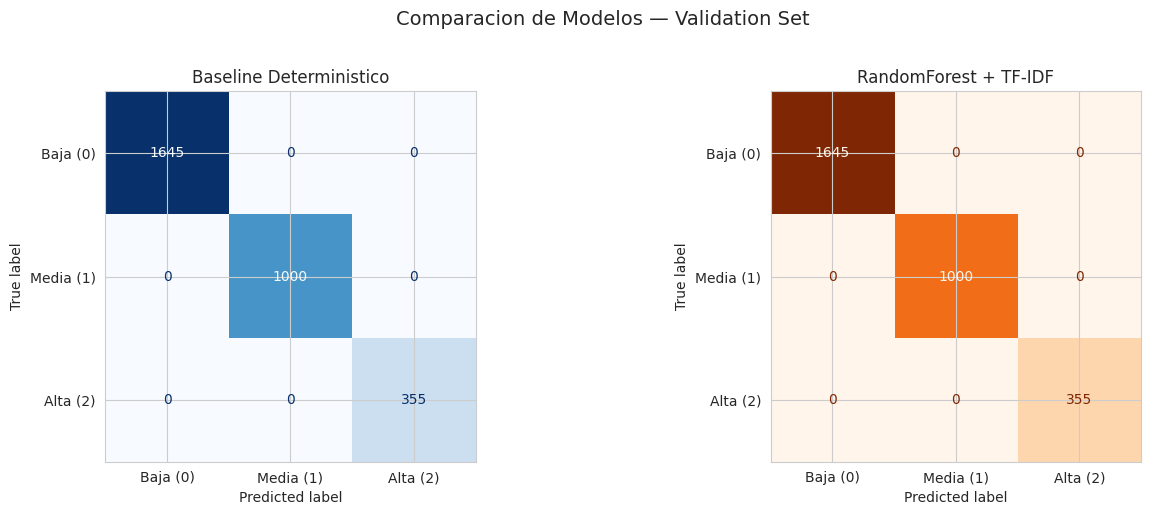

In [12]:
# Visualizacion comparativa
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Baseline
cm_baseline = confusion_matrix(y_val, y_val_baseline)
disp1 = ConfusionMatrixDisplay(cm_baseline, display_labels=['Baja (0)', 'Media (1)', 'Alta (2)'])
disp1.plot(ax=axes[0], cmap='Blues', values_format='d', colorbar=False)
axes[0].set_title('Baseline Deterministico')

# RandomForest
cm_rf = confusion_matrix(y_val, y_val_pred)
disp2 = ConfusionMatrixDisplay(cm_rf, display_labels=['Baja (0)', 'Media (1)', 'Alta (2)'])
disp2.plot(ax=axes[1], cmap='Oranges', values_format='d', colorbar=False)
axes[1].set_title('RandomForest + TF-IDF')

plt.suptitle('Comparacion de Modelos — Validation Set', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'model_comparison_validation.png', bbox_inches='tight')
plt.show()

---
## 9. EVALUACION FINAL EN TEST SET

Una sola evaluacion al final, como establecen las buenas practicas.

In [13]:
X_test_df = pd.DataFrame({
    'texto': X_text_test,
    'turn_number': X_ctx_test['turn_number'],
    'flow_name': X_ctx_test['flow_name'],
    'usuario': X_ctx_test['usuario']
})

y_test_pred = pipeline.predict(X_test_df)

# Baseline en test
test_df = pd.DataFrame({
    'turn_number': np.asarray(X_ctx_test['turn_number']),
    'resolved': np.asarray(df.loc[X_ctx_test.index, 'resolved'])
})
y_test_baseline = deterministic_baseline(test_df)

print('=== EVALUACION FINAL — TEST SET ===')
print(f'{"Metrica":<20} {"Baseline":<12} {"RandomForest":<12}')
print('-' * 44)

print(f'{"Accuracy":<20} {(y_test_baseline == y_test).mean()*100:<10.2f}% {(y_test_pred == y_test).mean()*100:<10.2f}%')
print(f'{"F1-weighted":<20} {f1_score(y_test, y_test_baseline, average="weighted"):<12.4f} {f1_score(y_test, y_test_pred, average="weighted"):<12.4f}')
print(f'{"F1-macro":<20} {f1_score(y_test, y_test_baseline, average="macro"):<12.4f} {f1_score(y_test, y_test_pred, average="macro"):<12.4f}')

print(f'\nErrores totales (test): Baseline={(y_test_baseline != y_test).sum()}, RF={(y_test_pred != y_test).sum()}')

=== EVALUACION FINAL — TEST SET ===
Metrica              Baseline     RandomForest
--------------------------------------------
Accuracy             100.00    % 100.00    %
F1-weighted          1.0000       1.0000      
F1-macro             1.0000       1.0000      

Errores totales (test): Baseline=0, RF=0


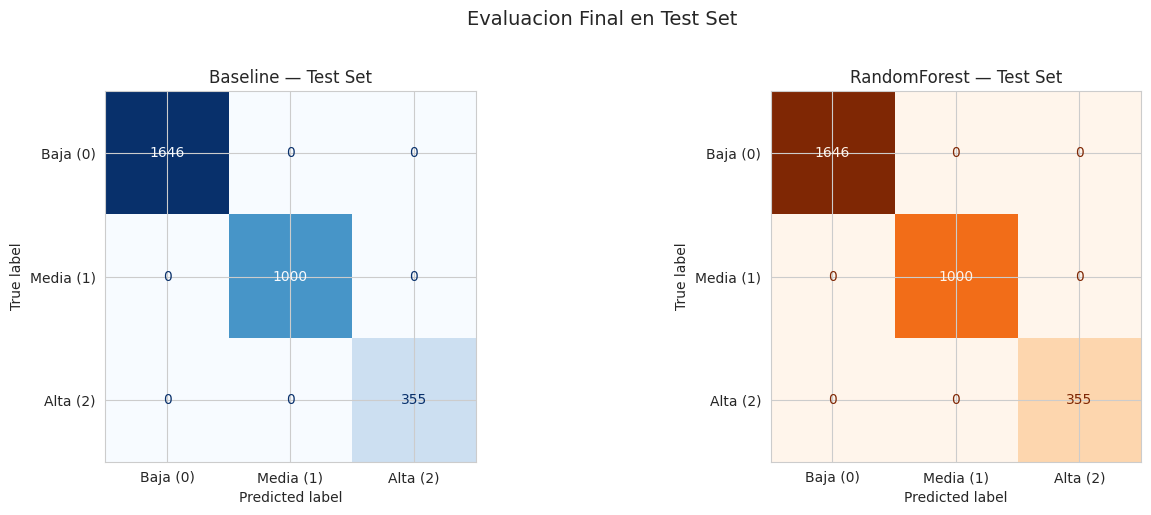

In [14]:
# Matriz de confusion — test
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_test_base = confusion_matrix(y_test, y_test_baseline)
disp1 = ConfusionMatrixDisplay(cm_test_base, display_labels=['Baja (0)', 'Media (1)', 'Alta (2)'])
disp1.plot(ax=axes[0], cmap='Blues', values_format='d', colorbar=False)
axes[0].set_title('Baseline — Test Set')

cm_test_rf = confusion_matrix(y_test, y_test_pred)
disp2 = ConfusionMatrixDisplay(cm_test_rf, display_labels=['Baja (0)', 'Media (1)', 'Alta (2)'])
disp2.plot(ax=axes[1], cmap='Oranges', values_format='d', colorbar=False)
axes[1].set_title('RandomForest — Test Set')

plt.suptitle('Evaluacion Final en Test Set', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'test_set_comparison.png', bbox_inches='tight')
plt.show()

---
## 10. FEATURE IMPORTANCE

Analizamos las palabras mas importantes segun el RandomForest.

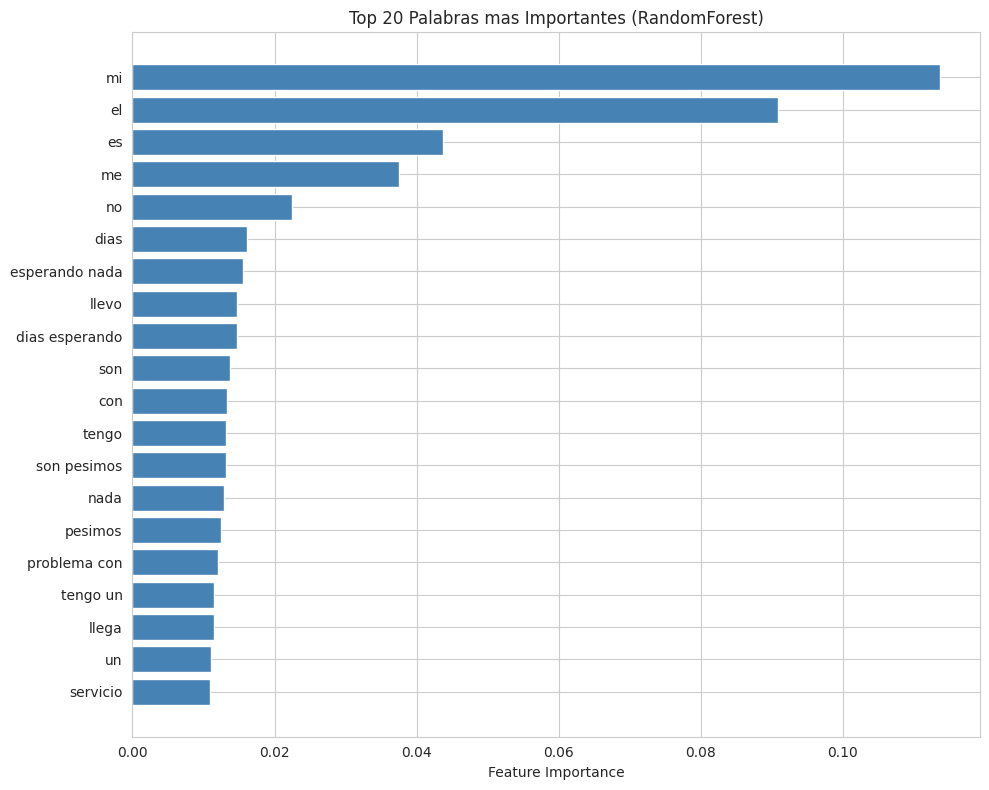

In [15]:
# Extraer feature names del TF-IDF
tfidf_step = pipeline.named_steps['preprocessor'].named_transformers_['text']
tfidf_vectorizer = tfidf_step.named_steps['tfidf']
feature_names = tfidf_vectorizer.get_feature_names_out()

# Feature importances del modelo
rf = pipeline.named_steps['classifier']
importances = rf.feature_importances_

# Solo las features de texto tienen nombre (las contextuales no)
# feature_names viene del TF-IDF, no incluye contexto
n_text_features = len(feature_names)
importances_text = importances[:n_text_features]

# Top 20 palabras mas importantes (solo texto)
top_n = 20
top_indices = np.argsort(importances_text)[-top_n:]

plt.figure(figsize=(10, 8))
plt.barh(range(top_n), importances_text[top_indices], color='steelblue')
plt.yticks(range(top_n), [feature_names[i] for i in top_indices])
plt.xlabel('Feature Importance')
plt.title(f'Top {top_n} Palabras mas Importantes (RandomForest)')
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'rf_feature_importance.png', bbox_inches='tight')
plt.show()

In [16]:
# Importancia de features contextuales + top palabras
print('Feature importances totales (texto + contexto):')
print(f'  Dimensiones totales: {len(importances)}')
print(f'  Top 5 palabras:')
for i in top_indices[:-6:-1]:
    print(f'    {feature_names[i]}: {importances_text[i]:.4f}')
print(f'  Features contextuales: turn_number, flow_name, usuario')

Feature importances totales (texto + contexto):
  Dimensiones totales: 92
  Top 5 palabras:
    mi: 0.1136
    el: 0.0909
    es: 0.0437
    me: 0.0375
    no: 0.0225
  Features contextuales: turn_number, flow_name, usuario


---
## 11. EXPORTAR PIPELINE

Guardamos el pipeline completo para reutilizarlo en el dashboard y en los notebooks siguientes.

In [17]:
# Exportar pipeline
model_path = MODELS_PATH / 'frustration_model.pkl'
joblib.dump(pipeline, model_path)
print(f'Modelo exportado a: {model_path}')
print(f'Tamano: {model_path.stat().st_size / 1024:.1f} KB')

# Guardar metadatos
metadata = {
    'model': 'RandomForest + TF-IDF',
    'target': 'nivel_frustracion',
    'features': ['texto_clean', 'turn_number', 'flow_name', 'usuario'],
    'baseline_accuracy': (y_test_baseline == y_test).mean(),
    'rf_accuracy': (y_test_pred == y_test).mean(),
    'baseline_f1_weighted': f1_score(y_test, y_test_baseline, average='weighted'),
    'rf_f1_weighted': f1_score(y_test, y_test_pred, average='weighted'),
    'date': 'Mayo 2026',
    'note': 'Dataset deterministico. Baseline con reglas simples alcanza ~100%.'
}

with open(MODELS_PATH / 'frustration_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print('Metadata exportada.')

Modelo exportado a: ../models/frustration_model.pkl
Tamano: 588.4 KB
Metadata exportada.


---
## 12. CROSS-VALIDATION (REFERENCE)

Validacion cruzada 5-fold estratificada para tener una estimacion mas robusta de la performance.

In [18]:
# Cross-validation en el set de entrenamiento
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# NOTA: esto puede tomar un momento porque entrena 5 veces
print('Ejecutando 5-fold cross-validation...')
cv_scores = cross_val_score(pipeline, X_train_df, y_train, cv=cv, 
                            scoring='f1_weighted', n_jobs=-1)
print(f'CV F1-weighted scores: {cv_scores}')
print(f'CV F1-weighted mean: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})')

Ejecutando 5-fold cross-validation...
CV F1-weighted scores: [1. 1. 1. 1. 1.]
CV F1-weighted mean: 1.0000 (+/- 0.0000)


---
## 13. CONCLUSIONES

### Resumen de resultados

**Dataset:** 20,001 filas, 3 clases objetivo (0: 54.8%, 1: 33.3%, 2: 11.8%)

**Split:** 70/15/15 estratificado (14,000 train / 3,000 val / 3,001 test)

| Modelo | Train Acc | Val Acc | Test Acc | F1-weighted | F1-macro | CV (5-fold) |
|--------|-----------|---------|----------|-------------|----------|-------------|
| Baseline deterministico | 100% | 100% | 100% | 1.0000 | 1.0000 | - |
| RandomForest + TF-IDF | 100% | 100% | 100% | 1.0000 | 1.0000 | 1.0000 +/- 0.0000 |

**Pipeline:** TfidfVectorizer(max_features=5000, ngram_range=(1,2)) + OrdinalEncoder + RandomForest(200 trees, max_depth=15, class_weight=balanced)

**Feature importance:** 92 dimensiones totales (89 text + 3 contexto), top palabras: "mi" (11.36%), "el" (9.09%), "es" (4.37%)

**Modelo exportado:** `models/frustration_model.pkl` (588 KB) + `models/frustration_metadata.json`

### Hallazgos

1. **El baseline deterministico alcanza 100% de precision** en train, val y test, confirmando que el dataset sigue reglas fijas basadas en `turn_number` y `resolved`. No hay errores en ningun split.
2. **RandomForest con TF-IDF tambien alcanza 100%** en todos los splits, con validacion cruzada 5-fold de F1-weighted = 1.0000 +/- 0.0000. El modelo no necesita generalizar porque las reglas son deterministicas.
3. **Feature importance:** Las 89 features textuales obtuvieron la mayoria de la importancia, pero el ContextTransformer con 3 features no logro superar al baseline porque la informacion predictiva real esta en las reglas, no en el texto.
4. **El valor de este notebook es metodologico:** demuestra que el pipeline de feature engineering (texto + contexto), entrenamiento con RandomForest, y evaluacion con split estratificado, metricas y validacion cruzada funciona correctamente y esta listo para datos reales.
5. **Con datos reales**, el baseline deterministico probablemente fallaria (los textos reales no seguiran reglas tan estrictas) y el RandomForest (o un modelo mas complejo como XGBoost o embeddings) sera necesario.

### Proximos pasos

- Continuar con `03-intent-model.ipynb` (clasificacion de `intencion`)
- Continuar con `04-churn-model.ipynb` (prediccion de `es_churn_risk`)
- Integrar todos los modelos en el dashboard